In [1]:
"""
Hyperparameter sensitivity analysis — MAPGU & Certified-SP
==========================================================
Sections
  1.  Anonymity threshold k  (MAPGU_k)
  1b. Anonymity threshold k  (MAPGU_k, CIFAR-10 / ResNet-18)
  2.  DP privacy budget ε    (MAPGU_ε, CIFAR-10 / ResNet-18)
  3.  Forget ratio            (MAPGU_k / MAPGU_ε)
  4.  Post-FT epochs          (Certified-SP)

Each section: fill in the DATA block → run the cell.
Labels and legend can be customised in each cell's Labels/legend block.

Figure sizing
-------------
All three plot functions share DEFAULT_FIGSIZE = (2.3, 2.1) so that every
saved PDF is identical in physical dimensions.  To place them in one LaTeX row:

    \\begin{figure}[t]
      \\centering
      \\includegraphics[width=0.32\\textwidth]{fig_k_sweep}%
      \\hfill
      \\includegraphics[width=0.32\\textwidth]{fig_eps_sweep}%
      \\hfill
      \\includegraphics[width=0.32\\textwidth]{fig_ft_epochs}
      \\caption{...}
    \\end{figure}
"""

import os
from mapgu.utils.plot_utils import apply_style, plot_sweep, plot_multi_sweep, plot_tradeoff

os.makedirs('results/figures', exist_ok=True)

apply_style()
print('Setup complete.')




Setup complete.


Saved: results/figures/k_sweep_heart_xgboost.pdf


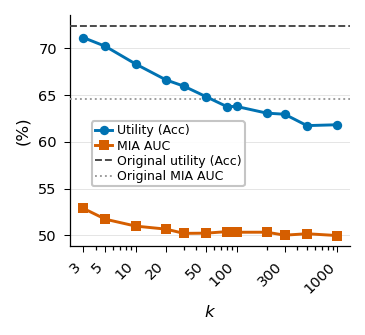

In [3]:
# ══════════════════════════════════════════════════════════════════════════════
# Section 1c — Anonymity threshold k  (MAPGU_k, Heart / XGBoost)
# ══════════════════════════════════════════════════════════════════════════════

# ── DATA ─────────────────────────────────────────────────────────────────────
K_VALS  = [3, 5, 10, 20, 30, 50, 80, 100, 200, 300, 500, 1000]

DATASET = 'Heart'
MODEL   = 'XGBoost'

UTIL     = [71.14429, 70.2, 68.30571, 66.61, 65.94857, 64.81571,
            63.76857, 63.78, 63.06429, 62.94857, 61.73143, 61.82429]
MIA      = [52.90094, 51.72902, 50.99433, 50.67226, 50.21903, 50.24206,
            50.40507, 50.33941, 50.34279, 50.02649, 50.1799,  49.98552]

UTIL_STD = None
MIA_STD  = None

TIME_S   = None
TIME_STD = None

ORIG_UTIL = 72.42714286
ORIG_MIA  = 64.58272194

YLIM_Q = None
YLIM_T = None

# ── Labels / legend ───────────────────────────────────────────────────────────
UTIL_LABEL      = 'Utility (Acc)'
MIA_LABEL       = 'MIA AUC'
ORIG_UTIL_LABEL = 'Original utility (Acc)'
ORIG_MIA_LABEL  = 'Original MIA AUC'
TIME_LABEL      = 'Unlearn time (s)'
LEGEND_KW       = dict(loc='center', ncol=1, bbox_to_anchor=(0.35, 0.4))
TIME_LEGEND_KW  = dict(loc='best')
# ── END DATA ──────────────────────────────────────────────────────────────────

DISPLAY_TICKS  = [3, 5, 10, 20, 50, 100, 300, 1000]
DISPLAY_LABELS = [str(k) for k in DISPLAY_TICKS]

plot_sweep(
    x=K_VALS, util=UTIL, mia=MIA,
    orig_util=ORIG_UTIL, orig_mia=ORIG_MIA,
    x_label='$k$',
    title='',
    util_label=UTIL_LABEL, mia_label=MIA_LABEL,
    orig_util_label=ORIG_UTIL_LABEL, orig_mia_label=ORIG_MIA_LABEL,
    time_label=TIME_LABEL,
    util_std=UTIL_STD, mia_std=MIA_STD,
    time_s=TIME_S, time_std=TIME_STD,
    log_x=True,
    x_ticks=DISPLAY_TICKS, x_ticklabels=DISPLAY_LABELS,
    ylim_q=YLIM_Q, ylim_t=YLIM_T,
    legend_kw=LEGEND_KW, time_legend_kw=TIME_LEGEND_KW,
    save_path=f'results/figures/k_sweep_{DATASET.lower()}_{MODEL.lower()}.pdf',
)



Saved: results/figures/eps_sweep_heart_xgboost.pdf


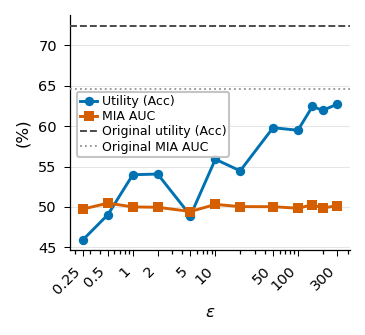

In [2]:

# ══════════════════════════════════════════════════════════════════════════════
# Section 2b — DP privacy budget ε  (MAPGU_ε, Heart / XGBoost)
# ══════════════════════════════════════════════════════════════════════════════

# ── DATA ─────────────────────────────────────────────────────────────────────
EPS_VALS = [0.25, 0.5, 1, 2, 5, 10, 20, 50, 100, 150, 200, 300]

DATASET = 'Heart'
MODEL   = 'XGBoost'

UTIL     = [45.96143, 49.05714, 53.99,    54.07429, 48.93857, 55.90429,
            54.47286, 59.80714, 59.49143, 62.44,    61.95429, 62.72143]
MIA      = [49.74815, 50.47804, 50.00903, 49.96568, 49.4406,  50.31882,
            50.0447,  50.03413, 49.84648, 50.26753, 49.86163, 50.17181]

UTIL_STD = None
MIA_STD  = None

TIME_S   = None
TIME_STD = None

ORIG_UTIL = 72.42714286
ORIG_MIA  = 64.58272194

YLIM_Q = None
YLIM_T = None

# ── Labels / legend ───────────────────────────────────────────────────────────
UTIL_LABEL      = 'Utility (Acc)'
MIA_LABEL       = 'MIA AUC'
ORIG_UTIL_LABEL = 'Original utility (Acc)'
ORIG_MIA_LABEL  = 'Original MIA AUC'
TIME_LABEL      = 'Unlearn time (s)'
LEGEND_KW       = dict(loc='upper left', ncol=1, bbox_to_anchor=(0., 0.7))
TIME_LEGEND_KW  = dict(loc='best')
# ── END DATA ──────────────────────────────────────────────────────────────────

DISPLAY_TICKS  = [0.25, 0.5, 1, 2, 5, 10, 50, 100, 300]
DISPLAY_LABELS = [str(e) for e in DISPLAY_TICKS]

plot_sweep(
    x=EPS_VALS, util=UTIL, mia=MIA,
    orig_util=ORIG_UTIL, orig_mia=ORIG_MIA,
    x_label=r'$\varepsilon$',
    title='',
    util_label=UTIL_LABEL, mia_label=MIA_LABEL,
    orig_util_label=ORIG_UTIL_LABEL, orig_mia_label=ORIG_MIA_LABEL,
    time_label=TIME_LABEL,
    util_std=UTIL_STD, mia_std=MIA_STD,
    time_s=TIME_S, time_std=TIME_STD,
    log_x=True,
    x_ticks=DISPLAY_TICKS, x_ticklabels=DISPLAY_LABELS,
    ylim_q=YLIM_Q, ylim_t=YLIM_T,
    legend_kw=LEGEND_KW, time_legend_kw=TIME_LEGEND_KW,
    save_path=f'results/figures/eps_sweep_{DATASET.lower()}_{MODEL.lower()}.pdf',
)


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# Section 4 — Post-FT epochs impact  (Certified-SP / CIFAR-10 / ResNet-18)
# ══════════════════════════════════════════════════════════════════════════════

# ── DATA ─────────────────────────────────────────────────────────────────────
EPOCH_VALS = [0, 3, 5, 10, 20, 30, 50]

SERIES = [
    {
        'label':    'MAPGU',
        'color':    '#0072B2',   # deep blue (Wong palette)
        'util':     [20.49, 77.924, 83.136,   87.866, 90.726,   91.678,   92.612],
        'mia':      [48.75, 47.06733728, 47.4874048, 48.1677888, 50.13695776, 50.1813584, 50.2120376],
        'util_std': [1.002, 0.473015856, 0.106320271, 0.168949697, 0.315505943, 0.124643492, 0.263165347],
        'mia_std':  [1.73, 0.369691057,  0.460697241, 0.330605277, 0.811820512, 0.622399338, 0.406281824],
    },
    {
        'label':    'Certified-SP',
        'color':    '#FDA800',   # amber/orange (Wong palette)
        'util':     [10.004, 41.65,   46.084,   52.812,   60.704,   65.35,   70.918],
        'mia':      [49.60069776, 48.10196272, 48.23923344, 47.90073424, 47.57359696, 47.5853616, 47.28649808],
        'util_std': [0.004898979, 0.690362224, 0.407950977, 0.548211638, 0.651386214, 0.883855192, 0.61590259],
        'mia_std':  [0.718962212,  0.283319933, 0.657799818, 0.427029599, 0.418859415, 0.479262529, 0.434712],
    },
]

# Dashed reference lines — retrained-model baseline
ORIG_UTIL       = 94.25
ORIG_MIA        = 50.04
ORIG_UTIL_LABEL = 'Retrain utility (Acc)'
ORIG_MIA_LABEL  = 'Retrain MIA AUC'

YLIM_Q = None

# ── Labels / legend ───────────────────────────────────────────────────────────
LEGEND_KW = dict(loc='lower right', ncol=1, bbox_to_anchor=(0.9, 0.0))
# ── END DATA ──────────────────────────────────────────────────────────────────

DISPLAY_TICKS  = [0, 5, 10, 20, 30, 50]
DISPLAY_LABELS = [str(e) for e in DISPLAY_TICKS]

plot_multi_sweep(
    x=EPOCH_VALS,
    series=SERIES,
    orig_util=ORIG_UTIL,
    orig_mia=ORIG_MIA,
    x_label='FT epochs',
    orig_util_label=ORIG_UTIL_LABEL,
    orig_mia_label=ORIG_MIA_LABEL,
    util_suffix=' utility (Acc)',
    mia_suffix=' MIA AUC',
    x_ticks=DISPLAY_TICKS,
    x_ticklabels=DISPLAY_LABELS,
    log_x=False,
    ylim_q=YLIM_Q,
    legend_kw=LEGEND_KW,
    save_path='results/figures/ft_epochs_sweep.pdf',
)

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# Section 1c — Anonymity threshold k  (MAPGU_k, CIFAR10 / ResNet18)
# ══════════════════════════════════════════════════════════════════════════════

# ── DATA ─────────────────────────────────────────────────────────────────────
K_VALS  = [2, 3,]

DATASET = 'CIFAR10'
MODEL   = 'ResNet18'

UTIL     = [68.44,58.56]
MIA      = [38.87,40.05223744]

UTIL_STD = [0.37, 0.27]
MIA_STD  = [0.61,0.902247639]



TIME_S   = None
TIME_STD = None

ORIG_UTIL = 72.42714286
ORIG_MIA  = 64.58272194

YLIM_Q = None
YLIM_T = None

# ── Labels / legend ───────────────────────────────────────────────────────────
UTIL_LABEL      = 'Utility (Acc)'
MIA_LABEL       = 'MIA AUC'
ORIG_UTIL_LABEL = 'Original utility (Acc)'
ORIG_MIA_LABEL  = 'Original MIA AUC'
TIME_LABEL      = 'Unlearn time (s)'
LEGEND_KW       = dict(loc='center', ncol=1, bbox_to_anchor=(0.35, 0.4))
TIME_LEGEND_KW  = dict(loc='best')
# ── END DATA ──────────────────────────────────────────────────────────────────

DISPLAY_TICKS  = [3, 5, 10, 20, 50, 100, 300, 1000]
DISPLAY_LABELS = [str(k) for k in DISPLAY_TICKS]

plot_sweep(
    x=K_VALS, util=UTIL, mia=MIA,
    orig_util=ORIG_UTIL, orig_mia=ORIG_MIA,
    x_label='$k$',
    title='',
    util_label=UTIL_LABEL, mia_label=MIA_LABEL,
    orig_util_label=ORIG_UTIL_LABEL, orig_mia_label=ORIG_MIA_LABEL,
    time_label=TIME_LABEL,
    util_std=UTIL_STD, mia_std=MIA_STD,
    time_s=TIME_S, time_std=TIME_STD,
    log_x=True,
    x_ticks=DISPLAY_TICKS, x_ticklabels=DISPLAY_LABELS,
    ylim_q=YLIM_Q, ylim_t=YLIM_T,
    legend_kw=LEGEND_KW, time_legend_kw=TIME_LEGEND_KW,
    save_path=f'results/figures/k_sweep_{DATASET.lower()}_{MODEL.lower()}.pdf',
)

